In [7]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW   # ✅ FIXED
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch.nn as nn
import nltk
from nltk.translate.bleu_score import sentence_bleu
from sklearn.utils.class_weight import compute_class_weight

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
train_path = "/content/train.csv"
test_path = "/content/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.head())

      id sentiment                                              tweet
0  23650  Positive  @user @user #israelis invented  #apaheid #goyi...
1  30284  Negative  the world looks better through   eyes. #julboe...
2   4175  Negative  i feel more for the animals that die in films ...
3  25714  Negative   @user check  @user   #fathersday #kids facing...
4   8738  Negative  @user #goodnews moving into our first home thi...


In [8]:
label_map = {label: idx for idx, label in enumerate(train_df['sentiment'].unique())}

train_df['sentiment'] = train_df['sentiment'].map(label_map)
test_df['sentiment'] = test_df['sentiment'].map(label_map)

num_classes = len(label_map)

print("Label Map:", label_map)

Label Map: {np.int64(0): 0, np.int64(1): 1}


In [9]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['sentiment']),
    y=train_df['sentiment']
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class Weights:", class_weights)

Class Weights: tensor([7.2917, 0.5368])


In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 128

In [11]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [12]:
train_dataset = SentimentDataset(
    train_df['tweet'].tolist(),
    train_df['sentiment'].tolist()
)

test_dataset = SentimentDataset(
    test_df['tweet'].tolist(),
    test_df['sentiment'].tolist()
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [13]:
class BertClassifier(nn.Module):
    def __init__(self, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.fc1 = nn.Linear(768, 100)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(100, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        x = self.fc1(cls_output)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertClassifier(num_classes)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# Apply class weights here
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.4531684130855969
Epoch 2, Loss: 0.2268232262028115
Epoch 3, Loss: 0.12663629953882524


In [16]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [23]:
accuracy = accuracy_score(true_labels, predictions)
print("Accuracy:", accuracy*100)

Accuracy: 94.35714285714286


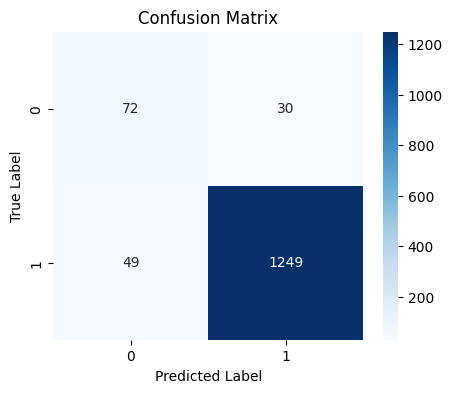


Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.71      0.65       102
           1       0.98      0.96      0.97      1298

    accuracy                           0.94      1400
   macro avg       0.79      0.83      0.81      1400
weighted avg       0.95      0.94      0.95      1400



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=sorted(label_map.values()),
            yticklabels=sorted(label_map.values()))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(true_labels, predictions))

In [28]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

bleu1, bleu2, bleu3, bleu4 = [], [], [], []

for ref, pred in zip(true_labels, predictions):
    ref_token = [str(ref)]
    pred_token = [str(pred)]

    bleu1.append(sentence_bleu([ref_token], pred_token, weights=(1,0,0,0), smoothing_function=smooth))
    bleu2.append(sentence_bleu([ref_token], pred_token, weights=(0.5,0.5,0,0), smoothing_function=smooth))
    bleu3.append(sentence_bleu([ref_token], pred_token, weights=(0.33,0.33,0.33,0), smoothing_function=smooth))
    bleu4.append(sentence_bleu([ref_token], pred_token, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth))

print("BLEU@1:", np.mean(bleu1))
print("BLEU@2:", np.mean(bleu2))
print("BLEU@3:", np.mean(bleu3))
print("BLEU@4:", np.mean(bleu4))

BLEU@1: 0.9435714285714286
BLEU@2: 0.29838348493445926
BLEU@3: 0.2064309360883828
BLEU@4: 0.16779336433295838


In [29]:
def show_examples(df, name):
    print(f"\n{name} Examples:\n")
    for i in range(5):
        text = df.iloc[i]['tweet']
        label = df.iloc[i]['sentiment']

        encoding = tokenizer(
            text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        output = model(input_ids, attention_mask)
        pred = torch.argmax(output, dim=1).item()

        print(f"Text: {text}")
        print(f"Actual: {label}, Predicted: {pred}")
        print("-"*50)

show_examples(train_df, "Train")
show_examples(test_df, "Test")


Train Examples:

Text: @user @user #israelis invented  #apaheid #goyim is their word for  @user @user
Actual: 0, Predicted: 0
--------------------------------------------------
Text: the world looks better through   eyes. #julboeyewear #julbo #maisonduski 
Actual: 1, Predicted: 1
--------------------------------------------------
Text: i feel more for the animals that die in films than humans ð±ð   #film4
Actual: 1, Predicted: 1
--------------------------------------------------
Text:  @user check  @user   #fathersday #kids facing single parenting issue coz of fake #women ...
Actual: 1, Predicted: 1
--------------------------------------------------
Text: @user #goodnews moving into our first home this weekend  
Actual: 1, Predicted: 1
--------------------------------------------------

Test Examples:

Text: #model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
Actual: 1, Predicted: 1
--------------------------------------------------
Text:  @user